# 04 · Análisis exploratorio (EDA)

**Proyecto:** LINE — Auditor Médico Digital · Health & Life IPS SAS

Explora el dataset maestro: distribución del target, tipos de alerta,
dimensiones institucionales (EPS, sede, tipo de atención), valores monetarios,
evolución temporal y el hallazgo estructural clave sobre los flags de cruce.

| Entrada | Salida |
|---|---|
| `data/processed/dataset_maestro.csv` | `outputs/figures/*.png` (10 figuras) |
| | `outputs/reports/eda_hallazgos.md`, `eda_stats.json` |

## 0 · Configuración (celda autocontenida)

In [1]:
from pathlib import Path
import json
import os
import time

import matplotlib

try:  # en notebook (IPython) el backend inline ya está activo
    get_ipython  # noqa: B018
except NameError:  # como script: backend sin ventanas para no bloquear
    matplotlib.use("Agg")

import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np
import pandas as pd

try:
    ROOT = Path(__file__).resolve().parents[1]
except NameError:
    ROOT = Path.cwd()
    if ROOT.name in ("notebooks", "src"):
        ROOT = ROOT.parent

DATA_PROC = ROOT / "data" / "processed"
OUT_FIG = ROOT / "outputs" / "figures"
OUT_REP = ROOT / "outputs" / "reports"
for _d in (OUT_FIG, OUT_REP):
    _d.mkdir(parents=True, exist_ok=True)

try:
    display  # noqa: B018
except NameError:
    display = print


def reintentar(fn, intentos=6, espera=0.5):
    for _i in range(intentos):
        try:
            return fn()
        except OSError:
            if _i == intentos - 1:
                raise
            time.sleep(espera * (2 ** _i))


def write_text_seguro(path, texto, encoding="utf-8"):
    path = Path(path)
    tmp = path.with_suffix(path.suffix + ".tmp")
    reintentar(lambda: tmp.write_text(texto, encoding=encoding))
    reintentar(lambda: os.replace(tmp, path))


ENTRADA = DATA_PROC / "dataset_maestro.csv"
assert ENTRADA.exists(), (
    f"FALTA INSUMO: {ENTRADA}\n→ Ejecuta primero el notebook 02_dataset_maestro.ipynb."
)

m = pd.read_csv(ENTRADA, parse_dates=["fecha_atencion"])

# Compatibilidad con el schema real del CSV procesado.
# El notebook original asumía columnas derivadas que no existen en dataset_maestro.csv.
m["tiene_prefactura"] = m["id_prefactura"].notna().astype(int)
m["tiene_soporte_hc"] = m["codigo_facturado_tiene_soporte_en_atencion"].fillna(0).astype(int)
m["codigo_coincide"] = (m["codigo_cups"] == m["codigo_cups_facturado"]).astype(int)
m["diferencia_cantidad"] = (m["cantidad_facturada"] - m["cantidad_realizada"]).fillna(0)

plt.rcParams.update({"figure.dpi": 110, "font.size": 10})
VERDE, ROJO = "#2e7d32", "#c62828"
hallazgos = []


def guardar(fig, nombre):
    """Guarda la figura en outputs/figures/ y la muestra inline."""
    fig.tight_layout()
    reintentar(lambda: fig.savefig(OUT_FIG / nombre, bbox_inches="tight"))
    plt.show()
    plt.close(fig)

print(f"Dataset maestro: {m.shape[0]:,} filas x {m.shape[1]} columnas")

Dataset maestro: 3,126 filas x 59 columnas


## 1 · Target y tipos de alerta
El 20.8 % de los registros son inconsistentes. Entre las alertas, dominan
SIN_SOPORTE_CLINICO y NO_FACTURADO — las dos de severidad ALTA.

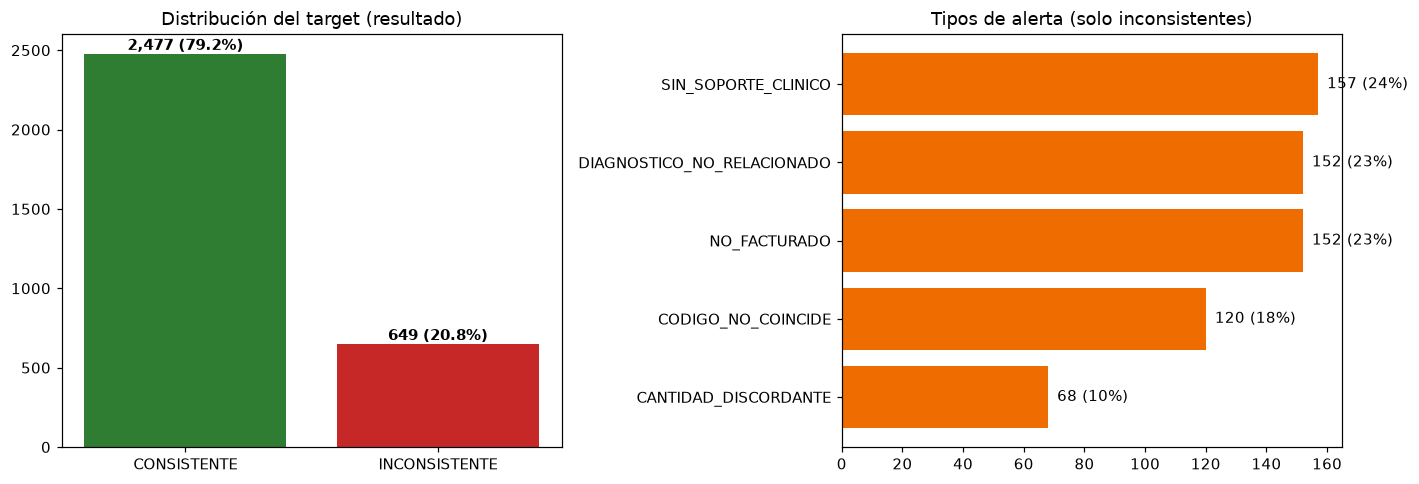

In [2]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
vc = m["resultado"].value_counts()
axes[0].bar(vc.index, vc.values, color=[VERDE, ROJO])
for i, v in enumerate(vc.values):
    axes[0].text(i, v + 25, f"{v:,} ({v/len(m)*100:.1f}%)", ha="center", fontweight="bold")
axes[0].set_title("Distribución del target (resultado)")
alertas = m.loc[m["resultado"] == "INCONSISTENTE", "tipo_alerta"].value_counts()
axes[1].barh(alertas.index, alertas.values, color="#ef6c00")
for i, v in enumerate(alertas.values):
    axes[1].text(v + 3, i, f"{v} ({v/alertas.sum()*100:.0f}%)", va="center")
axes[1].set_title("Tipos de alerta (solo inconsistentes)")
axes[1].invert_yaxis()
guardar(fig, "01_target_alertas.png")

hallazgos.append(
    f"**Target:** {vc.get('CONSISTENTE', 0):,} consistentes ({vc.get('CONSISTENTE', 0)/len(m)*100:.1f}%) vs "
    f"{vc.get('INCONSISTENTE', 0):,} inconsistentes ({vc.get('INCONSISTENTE', 0)/len(m)*100:.1f}%). "
    f"Alerta dominante: {alertas.index[0]} ({alertas.iloc[0]} casos).")

## 2 · Tasa de inconsistencia por dimensión institucional
Si el problema estuviera concentrado en una EPS/sede/médico, la intervención
sería local; si es homogéneo, el problema es de **proceso**.

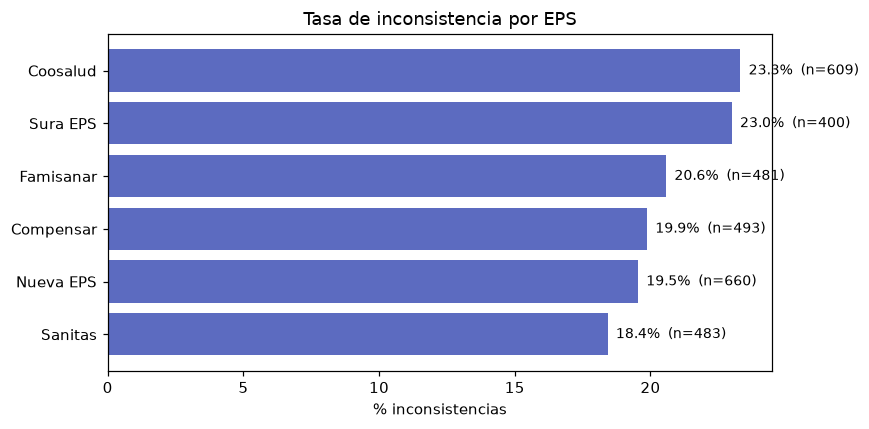

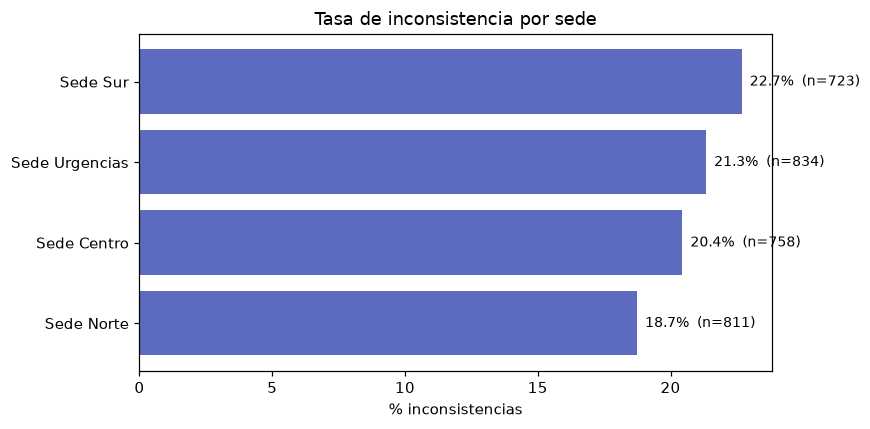

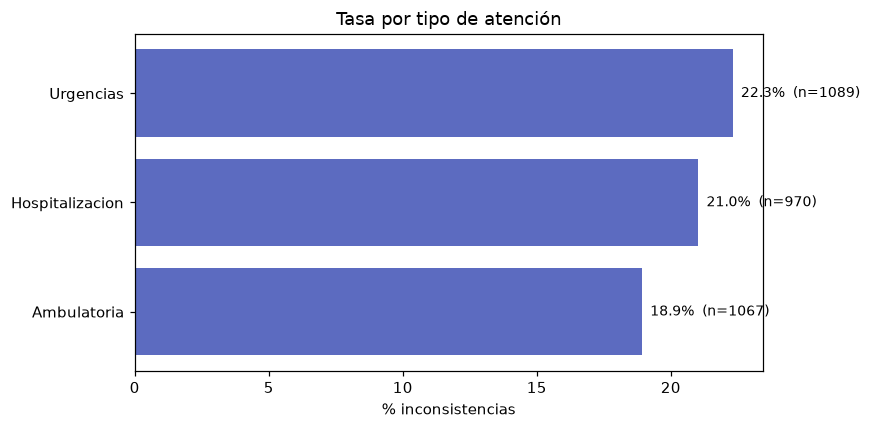

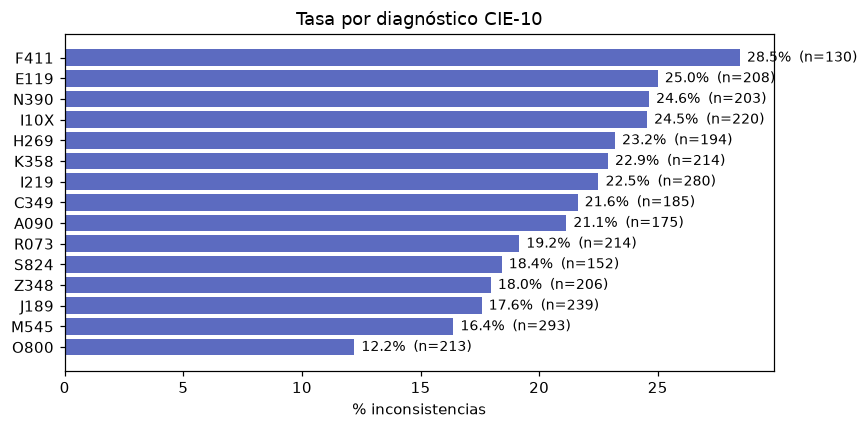

In [3]:
def tasa_por(col, titulo, fname, top=10):
    g = m.groupby(col)["target"].agg(["count", "mean"]).sort_values("mean", ascending=False).head(top)
    g["mean"] *= 100
    fig, ax = plt.subplots(figsize=(8, 4))
    ax.barh(g.index.astype(str), g["mean"], color="#5c6bc0")
    for i, (pct, n) in enumerate(zip(g["mean"], g["count"])):
        ax.text(pct + 0.3, i, f"{pct:.1f}%  (n={n})", va="center", fontsize=9)
    ax.set_title(titulo)
    ax.set_xlabel("% inconsistencias")
    ax.invert_yaxis()
    guardar(fig, fname)
    return g


g_eps = tasa_por("eps_atencion", "Tasa de inconsistencia por EPS", "02_tasa_eps.png")
g_sede = tasa_por("sede", "Tasa de inconsistencia por sede", "03_tasa_sede.png")
g_tipo = tasa_por("tipo_atencion", "Tasa por tipo de atención", "04_tasa_tipo_atencion.png")
g_diag = tasa_por("diagnostico_principal_cie10", "Tasa por diagnóstico CIE-10",
                  "05_tasa_diagnostico.png", top=15)

hallazgos.append(
    f"**Dimensiones:** tasa homogénea entre EPS ({g_eps['mean'].min():.1f}%–{g_eps['mean'].max():.1f}%) "
    f"y sedes ({g_sede['mean'].min():.1f}%–{g_sede['mean'].max():.1f}%): problema transversal/sistémico.")

## 3 · CUPS con mayor tasa de inconsistencia (n≥30)

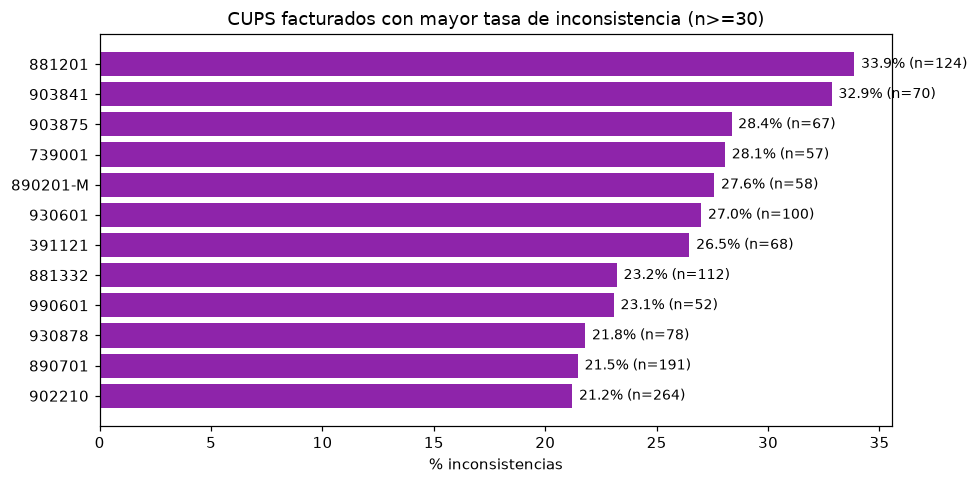

In [4]:
g_cups = m.groupby("codigo_cups_facturado")["target"].agg(["count", "mean"])
g_cups = g_cups[g_cups["count"] >= 30].sort_values("mean", ascending=False).head(12)
g_cups["mean"] *= 100
fig, ax = plt.subplots(figsize=(9, 4.5))
ax.barh(g_cups.index.astype(str), g_cups["mean"], color="#8e24aa")
for i, (pct, n) in enumerate(zip(g_cups["mean"], g_cups["count"])):
    ax.text(pct + 0.3, i, f"{pct:.1f}% (n={n})", va="center", fontsize=9)
ax.set_title("CUPS facturados con mayor tasa de inconsistencia (n>=30)")
ax.set_xlabel("% inconsistencias")
ax.invert_yaxis()
guardar(fig, "06_tasa_cups.png")

## 4 · Valores monetarios y pérdida estimada por fugas
La fuga (procedimiento con soporte clínico sin facturar) se identifica con
`id_prefactura` nulo (`tiene_prefactura == 0`).

**Método de estimación (corregido en la revisión del 26-jul-2026):** la versión
anterior multiplicaba las 152 fugas por el promedio de `valor_unitario` de
*todo* el maestro — promedio que incluía los **ceros imputados de las propias
fugas** (y de los ítems sin prefactura), subestimando la pérdida. Ahora cada
fuga se valora con el **precio de referencia de su propio código CUPS**
(promedio del valor unitario realmente facturado para ese código) multiplicado
por la **cantidad realizada** registrada en la historia clínica. Se reporta
también la estimación simple (promedio global de ítems facturados) como cota
conservadora.


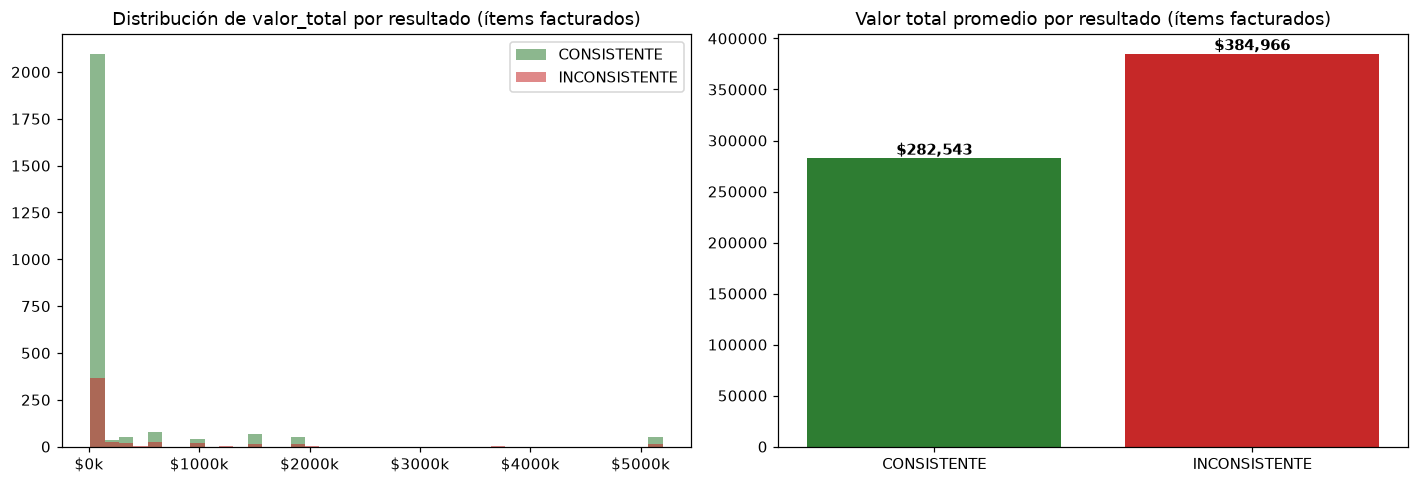

Pérdida estimada por código CUPS (precio de referencia x cantidad realizada):


,n_fugas,precio_ref,valor_estimado
codigo_cups,,,
391201,7,"$5,200,000","$36,400,000"
391013,14,"$1,450,000","$20,300,000"
391121,4,"$1,850,000","$7,400,000"
930878,4,"$620,000","$2,480,000"
881201,15,"$95,000","$1,995,000"
930601,4,"$320,000","$1,600,000"
881332,9,"$110,000","$1,320,000"
990601,10,"$130,000","$1,300,000"
871111,17,"$55,000","$1,155,000"


**Fugas (sin prefactura):** 152 procedimientos con soporte clínico sin facturar. Pérdida estimada: $78,046,000 COP valorando cada fuga con el precio de referencia de su CUPS × cantidad realizada (0 sin precio de referencia, valoradas al promedio). Estimación conservadora con promedio simple de ítems facturados ($287,476): $43,696,371.


In [5]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
con_valor = m[m["valor_total"] > 0]  # solo ítems realmente facturados (excluye ceros imputados)
for res, color in [("CONSISTENTE", VERDE), ("INCONSISTENTE", ROJO)]:
    axes[0].hist(con_valor.loc[con_valor["resultado"] == res, "valor_total"],
                 bins=40, alpha=0.55, label=res, color=color)
axes[0].legend()
axes[0].set_title("Distribución de valor_total por resultado (ítems facturados)")
axes[0].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, p: f"${x/1000:.0f}k"))
med = con_valor.groupby("resultado")["valor_total"].mean()
axes[1].bar(med.index, med.values, color=[VERDE, ROJO])
for i, v in enumerate(med.values):
    axes[1].text(i, v, f"${v:,.0f}", ha="center", va="bottom", fontweight="bold")
axes[1].set_title("Valor total promedio por resultado (ítems facturados)")
guardar(fig, "07_valores.png")

# --- Pérdida por fugas: precio de referencia del CUPS de cada fuga x cantidad realizada ---
fugas = m[m["tiene_prefactura"] == 0]
facturados = m[m["valor_unitario"] > 0]
precio_ref_cups = facturados.groupby("codigo_cups_facturado")["valor_unitario"].mean()
valor_prom = facturados["valor_unitario"].mean()  # promedio de ítems facturados (sin ceros imputados)

fugas_precio = fugas["codigo_cups"].map(precio_ref_cups)
sin_ref = int(fugas_precio.isna().sum())
fugas_precio = fugas_precio.fillna(valor_prom)
fugas_cantidad = fugas["cantidad_realizada"].clip(lower=1)
perdida = float((fugas_precio * fugas_cantidad).sum())
perdida_promedio_simple = len(fugas) * valor_prom

detalle_fugas = (fugas.assign(precio_ref=fugas_precio, cantidad=fugas_cantidad,
                              valor_estimado=fugas_precio * fugas_cantidad)
                 .groupby("codigo_cups")
                 .agg(n_fugas=("id_cruce", "count"), precio_ref=("precio_ref", "first"),
                      valor_estimado=("valor_estimado", "sum"))
                 .sort_values("valor_estimado", ascending=False))
print("Pérdida estimada por código CUPS (precio de referencia x cantidad realizada):")
vista_fugas = detalle_fugas.copy()
for c in ("precio_ref", "valor_estimado"):
    vista_fugas[c] = vista_fugas[c].map("${:,.0f}".format)
display(vista_fugas)

hallazgos.append(
    f"**Fugas (sin prefactura):** {len(fugas)} procedimientos con soporte clínico sin facturar. "
    f"Pérdida estimada: ${perdida:,.0f} COP valorando cada fuga con el precio de referencia de su "
    f"CUPS × cantidad realizada ({sin_ref} sin precio de referencia, valoradas al promedio). "
    f"Estimación conservadora con promedio simple de ítems facturados (${valor_prom:,.0f}): "
    f"${perdida_promedio_simple:,.0f}.")
print(hallazgos[-1])

## 5 · Evolución temporal

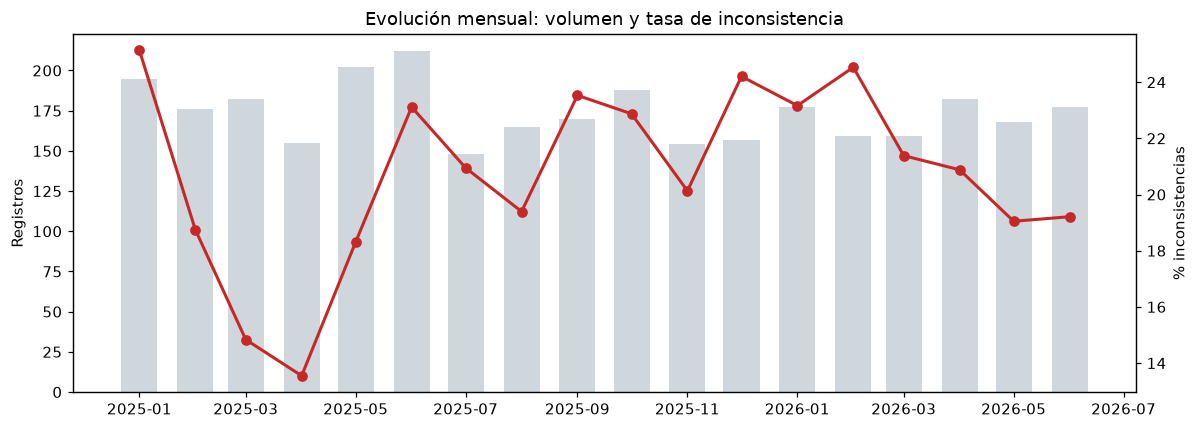

In [6]:
ts = m.set_index("fecha_atencion").sort_index()
mensual = ts.groupby(pd.Grouper(freq="MS")).agg(total=("target", "count"), tasa=("target", "mean"))
mensual["tasa"] *= 100
fig, ax1 = plt.subplots(figsize=(11, 4))
ax1.bar(mensual.index, mensual["total"], width=20, alpha=0.3, color="#607d8b", label="Registros")
ax2 = ax1.twinx()
ax2.plot(mensual.index, mensual["tasa"], color=ROJO, marker="o", lw=2, label="% inconsistencias")
ax1.set_title("Evolución mensual: volumen y tasa de inconsistencia")
ax1.set_ylabel("Registros")
ax2.set_ylabel("% inconsistencias")
guardar(fig, "08_serie_temporal.png")
hallazgos.append(
    f"**Temporal:** tasa mensual estable entre {mensual['tasa'].min():.1f}% y "
    f"{mensual['tasa'].max():.1f}% — sin estacionalidad fuerte; errores a ritmo constante.")

## 6 · Diferencias de cantidad

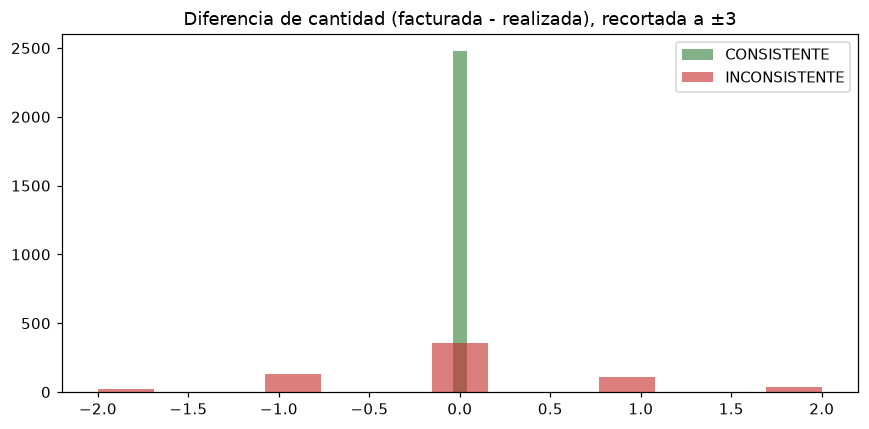

In [7]:
fig, ax = plt.subplots(figsize=(8, 4))
dif = m["diferencia_cantidad"].clip(-3, 3)
for res, color in [("CONSISTENTE", VERDE), ("INCONSISTENTE", ROJO)]:
    ax.hist(dif[m["resultado"] == res], bins=13, alpha=0.6, label=res, color=color)
ax.set_title("Diferencia de cantidad (facturada - realizada), recortada a ±3")
ax.legend()
guardar(fig, "09_diferencia_cantidad.png")

pct_dif = (m.loc[m["target"] == 1, "diferencia_cantidad"] != 0).mean() * 100
hallazgos.append(
    f"**Cantidades:** el {pct_dif:.0f}% de los inconsistentes tiene diferencia de cantidad != 0.")

## 7 · Hallazgo estructural: los flags de cruce son casi deterministas
Probabilidad de INCONSISTENTE dado cada flag computable en producción. Este es
el hallazgo que explica el techo de los modelos: 4 de los 5 tipos de alerta se
derivan directamente de reglas; la clase difícil real es
DIAGNOSTICO_NO_RELACIONADO.

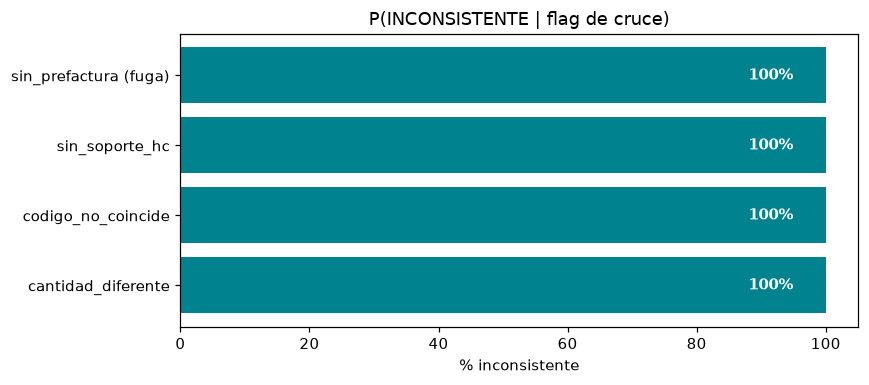

In [8]:
tabla_flags = {
    "sin_prefactura (fuga)": float(m.loc[m["tiene_prefactura"] == 0, "target"].mean()),
    "sin_soporte_hc": float(m.loc[m["tiene_soporte_hc"] == 0, "target"].mean()),
    "codigo_no_coincide": float(m.loc[m["codigo_coincide"] == 0, "target"].mean())
        if (m["codigo_coincide"] == 0).any() else np.nan,
    "cantidad_diferente": float(m.loc[m["diferencia_cantidad"] != 0, "target"].mean()),
}
fig, ax = plt.subplots(figsize=(8, 3.6))
keys = list(tabla_flags)
vals = [tabla_flags[k] * 100 for k in keys]
ax.barh(keys, vals, color="#00838f")
for i, v in enumerate(vals):
    ax.text(v - 5, i, f"{v:.0f}%", va="center", ha="right", color="white", fontweight="bold")
ax.set_title("P(INCONSISTENTE | flag de cruce)")
ax.set_xlabel("% inconsistente")
ax.invert_yaxis()
guardar(fig, "10_flags_cruce.png")

hallazgos.append(
    "**Flags de cruce:** casi deterministas — "
    + ", ".join(f"{k}: {v*100:.0f}%" for k, v in tabla_flags.items() if not np.isnan(v))
    + ". El target fue generado por reglas cuyos insumos están en estas features; el valor del "
      "modelo es priorizar por probabilidad y generalizar, no redescubrir las reglas.")

## 8 · Exportar hallazgos → `outputs/reports/`

In [9]:
texto = ["# Hallazgos EDA — dataset maestro", ""]
for i, h in enumerate(hallazgos, 1):
    texto += [f"{i}. {h}", ""]
write_text_seguro(OUT_REP / "eda_hallazgos.md", "\n".join(texto))

write_text_seguro(OUT_REP / "eda_stats.json", json.dumps({
    "target": vc.to_dict(),
    "alertas": alertas.to_dict(),
    "flags_cruce_prob_inconsistente": tabla_flags,
    "perdida_estimada_fugas": perdida,
    "perdida_estimada_promedio_simple": float(perdida_promedio_simple),
    "metodo_perdida": "precio de referencia por CUPS x cantidad realizada (fallback: promedio de items facturados)",
    "n_fugas": int(len(fugas)),
    "valor_unitario_promedio": float(valor_prom),
}, ensure_ascii=False, indent=2))

figs_eda = [f for f in OUT_FIG.glob("*.png") if f.name[:2].isdigit() and 1 <= int(f.name[:2]) <= 10]
print(f"Figuras : {len(figs_eda)} PNG del EDA en {OUT_FIG} (la carpeta también guarda las figuras del nb 05)")
print(f"Reportes: eda_hallazgos.md + eda_stats.json en {OUT_REP}")

Figuras : 10 PNG del EDA en C:\Users\ivanp\Desktop\FINAL_CAPSTONE\outputs\figures (la carpeta también guarda las figuras del nb 05)
Reportes: eda_hallazgos.md + eda_stats.json en C:\Users\ivanp\Desktop\FINAL_CAPSTONE\outputs\reports


## ✅ Verificación de cierre
Deben existir las **10 figuras del EDA** (`01_*.png` … `10_*.png`) en
`outputs/figures/` y los dos reportes en `outputs/reports/`. Los **6 hallazgos**
numerados quedan en `eda_hallazgos.md` (si aparecen menos, el notebook se
ejecutó parcialmente: reiniciar kernel y correr de arriba a abajo).
